# Churn Analysis

In [1]:
# Import Packages
import pandas as pd
import numpy as np
np.random.seed(1)
import matplotlib.pyplot as plt
import seaborn as sns

import math
from datetime import datetime, timedelta

import statsmodels.api as sm
#import scikit-learn
#import jupyterlab
#import xgboost

# Set Display Preferences
pd.set_option('display.max_columns', None)
pd.options.display.float_format = "{:.2f}".format

In [35]:
from scipy.stats import loguniform, randint, uniform

## Prepare Data

### Load data & remove duplicate entries

In [2]:
### UK Based ecom retailer sales from Jan 12, 2009 to Sep 12, 2011.
### Mainly sells unique all-occasion gift-ware.
df1 = pd.read_excel("data/online_retail_II.xlsx", sheet_name='Year 2009-2010', header=0)
df2 = pd.read_excel("data/online_retail_II.xlsx", sheet_name='Year 2010-2011', header=0)

### Note: Both excel sheets contain 2010 sales. Duplicates must be removed before concatenating.
# There is 1 week of overlap in the datasets
print(df1['InvoiceDate'].max())
print(df2['InvoiceDate'].min())

# Remove duplicate entries 
df1 = df1[~df1["Invoice"].isin(df2['Invoice'].unique())]
# Note: achives identical result as -> df1[df1['InvoiceDate']<df2['InvoiceDate'].min()] 

2010-12-09 20:01:00
2010-12-01 08:26:00


### Define new factors

In [3]:
### Merge the dataframes from each year
df = pd.concat([df1, df2], axis=0, ignore_index=True)

### Create a Invoice Amount column
df['Invoice Amount'] = df['Price'] * df['Quantity']

### Sales are overwhelmingly from the UK.
uk_pct = len(df[df['Country']=='United Kingdom']) / len(df)
print(f'Percent of entries sold in the UK: {uk_pct*100:.2f}%')
# Create a binary variable indicating UK vs. Global.
df['UK_Ind'] = np.where(df['Country']=='United Kingdom', 1, 0)

### Remove time component from Invoice Date
df['InvoiceDate'] = df['InvoiceDate'].dt.date

df_orig = df.copy()
df.head(10)

Percent of entries sold in the UK: 91.88%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Invoice Amount,UK_Ind
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085.00,United Kingdom,83.40,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085.00,United Kingdom,81.00,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085.00,United Kingdom,81.00,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085.00,United Kingdom,100.80,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085.00,United Kingdom,30.00,1
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01,1.65,13085.00,United Kingdom,39.60,1
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01,1.25,13085.00,United Kingdom,30.00,1
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01,5.95,13085.00,United Kingdom,59.50,1
8,489435,22350,CAT BOWL,12,2009-12-01,2.55,13085.00,United Kingdom,30.60,1
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01,3.75,13085.00,United Kingdom,45.00,1


### Remove null customer IDs & non-purchase invoice entries

In [4]:
### Null Customer IDs (required to determine churn). 
### Reason for missing Customer ID is unknown. For simplicity, these entries will be excluded from the analysis. This likely creates a source of bias.
### Recomendation is to update the ordering platform to require purchasers to create an account & generate a unique Customer ID.
null_id_pct = sum(df['Customer ID'].isnull()) / len(df)
print(f'Percent of entries that are missing Customer ID: {null_id_pct*100:.2f}%')


### Some items have a price of $0. These entries will not count towards orders.
### Primarily consisting of stickers, car flags, shipping materials & invoice notes.
non_items = len(df[df['Price']==0]) / len(df)
print(f'Percent of entries that had a price of $0: {non_items*100:.2f}%')


### Examining the Stock Codes, entries starting with alphabetic characters are atypical invoice entries that do not represent merchandise sales.
### Ex. Test products, adjustments, postage, carriage, etc.
df["StockCode"] = df["StockCode"].astype(str)
stockcode = (
    df.groupby(["StockCode", "Description"])["Quantity"]
      .sum()
      .reset_index()        
      .sort_values("StockCode", ascending=False)
    )

stockcode_pct = sum(~df['StockCode'].str.match(r'^\d')) / len(df)
print(f'Percent of entries that have invalid Stock Codes: {stockcode_pct*100:.2f}%')


### Remove entries is no Customer ID or Price = $0
df = df[~df['Customer ID'].isnull()]
df = df[df['Price']!=0]
### Remove entries for Stock Codes beginning with alphabetic characters
df = df[df['StockCode'].str.match(r'^\d')]

Percent of entries that are missing Customer ID: 22.52%
Percent of entries that had a price of $0: 0.58%
Percent of entries that have invalid Stock Codes: 0.57%


### Define function that aggregates data by Customer

In [5]:
### Define aggragation function
def aggregate_by_cx(df):
    """
    Aggregate transaction data & group it by Customer ID
    """
    df = df.reset_index()
    df_aggregated = df.groupby(['Customer ID', 'UK_Ind'], as_index=False).agg(
        # First & last txn in the measurement period
        first_txn = ('InvoiceDate', 'min'),
        last_txn = ('InvoiceDate', 'max'),
        # Transaction Count
        total_txns = ('Invoice', 'nunique'),
        sale_txns = ('Invoice', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique()),
        return_txns = ('Invoice', lambda x: x[df.loc[x.index, 'Quantity'] < 0].nunique()),
        # Sales amount ($)
        total_amt = ('Invoice Amount', 'sum'),
        sale_amt = ('Invoice Amount', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].sum()),
        return_amt = ('Invoice Amount', lambda x: x[df.loc[x.index, 'Quantity'] < 0].sum()),
        # Sale quantity
        total_qty = ('Quantity', 'sum'),
        sale_qty = ('Quantity', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].sum()),
        return_qty = ('Quantity', lambda x: x[df.loc[x.index, 'Quantity'] < 0].sum()),
        # Variaty of SKUs
        total_skus = ('StockCode', 'nunique'),
        sale_skus = ('StockCode', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique()),
        # Frequency
        total_frequency = ('InvoiceDate', 'nunique'),
        sale_frequency = ('InvoiceDate', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique())
        )

    # Returns Percent
    df_aggregated['return_pct'] = -1*df_aggregated['return_amt'] / (-1*df_aggregated['return_amt'] + df_aggregated['sale_amt'])
    # Units per Transaction
    df_aggregated['upt'] = df_aggregated['sale_qty'] / df_aggregated['sale_txns']
    # Average Unit Retail
    df_aggregated['aur'] = df_aggregated['sale_amt'] / df_aggregated['sale_qty']          
    # Average Order Value
    df_aggregated['aov'] = df_aggregated['sale_amt'] / df_aggregated['sale_txns']
    # SKU Mix per Order
    df_aggregated['sku_mix'] = df_aggregated['total_skus'] / df_aggregated['total_txns']

    # Replace NaN for UPT/AUR/AOV in for pure return customers
    df_aggregated.fillna(0, inplace=True)

    # Single purchase customers
    df_aggregated['cx_single_purchase'] = (df_aggregated['sale_txns'] == 1).astype(int)
    # Return only customers
    df_aggregated['cx_return_only'] = (df_aggregated['sale_txns'] == 0).astype(int)


    return df_aggregated

In [6]:
### Check to confirm there are no Customer IDs found in multiple markets/countries
df_aggregated = aggregate_by_cx(df)
cx_market = df_aggregated.groupby("Customer ID")["UK_Ind"].count()
multi_market_cx = sum(cx_market>1)
print('Number of customers in multiple markets:', multi_market_cx)

Number of customers in multiple markets: 0


### Calculate Temporal factors

In [7]:
def calc_temporal_factors(df, n):
    """
    Takes dataframe, split by time windows, aggregate & calculate customer perchase data by period. Then calculate temporal factors (ex. streak/recency/churn).
    n = number of days per observation period.
    """
    ### Churn will be definited by if a customer purchases in the next N days.
    ### The past N days will be used to train a model that predicts likelihood to churn. This will be called the observation window.
    ### The dataset spans 2 years, so this approach evaluates churn using a recurant sliding window approach.
    observation_days = n
    observation_periods = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days / observation_days
    observation_periods = int(math.floor(observation_periods))
    print('Number of', observation_days, 'day periods:', observation_periods, '\n')

    # Slice data by observation period starting from most recent & working backward by increments equal to the duration of the observation period
    end = df['InvoiceDate'].max()
    df_x = pd.DataFrame()
    for i in range(observation_periods):
        # Get start & end date for the given observation period.
        period_end = end
        period_start = period_end - timedelta(observation_days)
        # Create a temporary dataframe for the observation period. Aggregate by Customer ID & compute customer satistics.
        df_i = df[df['InvoiceDate'].between(period_start,period_end)]
        df_i = aggregate_by_cx(df_i)
        
        # Tag if customer churns in next period (churn defined by having at least 1 sale transaction in the next period)
        if i==0:
            churn_ind = np.nan
        else:
            churn_ind = df_i['Customer ID'].isin(df_next_period.loc[df_next_period['sale_txns'] > 0, 'Customer ID']).map({True: 0, False: 1})

        # Define new columns for Churn Indicator & Observation Period
        df_i.insert(loc=0, column='churn_ind', value=churn_ind)
        df_i.insert(loc=0, column='Period', value=observation_periods-i)
        df_i.insert(loc=0, column='Observation End', value=period_end)
        df_i.insert(loc=0, column='Observation Start', value=period_start)

        # Calculate recency from end of period to most recent trasnaction 
        df_i['Recency'] = end - df_i['last_txn']
        df_i['Recency'] = pd.to_timedelta(df_i['Recency'])
        df_i['Recency'] = df_i['Recency'].dt.days

        # Concatenate each period's customer data into a single dataframe
        df_x = pd.concat([df_x, df_i], ignore_index=True)

        # Updated end date for next period
        df_next_period = df_i.copy()
        end = period_start - timedelta(days=1)

    ### Calculate number of consecutive previous periods with purchase for each Customer ID
    df_x = df_x.sort_values(['Customer ID', 'Period'])
    # Detect start of streak
    df_x['streak_start'] = df_x.groupby('Customer ID')['Period'].diff().ne(1)
    # Assign streak ids
    df_x['streak_id'] = df_x.groupby('Customer ID')['streak_start'].cumsum()
    # Compute streak length within each streak group
    streak_length = df_x.groupby(['Customer ID','streak_id']).cumcount()
    df_x.insert(loc=3, column='streak_length', value=streak_length)
    df_x.drop(['streak_start', 'streak_id'], axis=1, inplace=True)

    # Sort data
    df_x = df_x.sort_values(by=['Customer ID', 'Observation Start'],ignore_index=True)

    # Remove final period as it is only used to define churn in period N-1
    df_x = df_x[df_x['Period']<observation_periods]
    df_x['churn_ind'] = df_x['churn_ind'].astype(int)
    
    return df_x


In [8]:
### This will be our primary dataframe for analysis where churn is defined by no purchase per 180 days
df_180 = calc_temporal_factors(df, 180)
df_180.head(5)

Number of 180 day periods: 4 



,Observation Start,Observation End,Period,streak_length,churn_ind,Customer ID,UK_Ind,first_txn,last_txn,total_txns,sale_txns,return_txns,total_amt,sale_amt,return_amt,total_qty,sale_qty,return_qty,total_skus,sale_skus,total_frequency,sale_frequency,return_pct,upt,aur,aov,sku_mix,cx_single_purchase,cx_return_only,Recency
0,2009-12-16,2010-06-14,1,0,0,12346.00,1,2010-03-02,2010-03-02,1,1,0,27.05,27.05,0.00,5,5,0,5,5,1,1,-0.00,5.00,5.41,27.05,5.00,1,0,104
1,2010-06-15,2010-12-12,2,1,0,12346.00,1,2010-06-28,2010-06-28,1,1,0,142.31,142.31,0.00,19,19,0,19,19,1,1,-0.00,19.00,7.49,142.31,19.00,1,0,167
2,2010-12-13,2011-06-11,3,2,1,12346.00,1,2011-01-18,2011-01-18,2,1,1,0.00,77183.60,-77183.60,0,74215,-74215,1,1,1,1,0.50,74215.00,1.04,77183.60,0.50,1,0,144
3,2010-06-15,2010-12-12,2,0,0,12347.00,0,2010-10-31,2010-12-07,2,2,0,1323.32,1323.32,0.00,828,828,0,70,70,2,2,-0.00,414.00,1.60,661.66,35.00,0,0,5
4,2010-12-13,2011-06-11,3,1,0,12347.00,0,2011-01-26,2011-06-09,3,3,0,1494.16,1494.16,0.00,994,994,0,58,58,3,3,-0.00,331.33,1.50,498.05,19.33,0,0,2


In [9]:
### This is a secondary dataframe with 90 day lapsing definition we will use to  look at longer horizon time metrcs. 
# Example: Streak & CX type (new, lapsed, returns, high value).
df_90 = calc_temporal_factors(df, 90)
df_90.head(5)

Number of 90 day periods: 8 



,Observation Start,Observation End,Period,streak_length,churn_ind,Customer ID,UK_Ind,first_txn,last_txn,total_txns,sale_txns,return_txns,total_amt,sale_amt,return_amt,total_qty,sale_qty,return_qty,total_skus,sale_skus,total_frequency,sale_frequency,return_pct,upt,aur,aov,sku_mix,cx_single_purchase,cx_return_only,Recency
0,2009-12-12,2010-03-12,1,0,1,12346.00,1,2010-03-02,2010-03-02,1,1,0,27.05,27.05,0.00,5,5,0,5,5,1,1,-0.00,5.00,5.41,27.05,5.00,1,0,10
1,2010-06-12,2010-09-10,3,0,1,12346.00,1,2010-06-28,2010-06-28,1,1,0,142.31,142.31,0.00,19,19,0,19,19,1,1,-0.00,19.00,7.49,142.31,19.00,1,0,74
2,2010-12-11,2011-03-11,5,0,1,12346.00,1,2011-01-18,2011-01-18,2,1,1,0.00,77183.60,-77183.60,0,74215,-74215,1,1,1,1,0.50,74215.00,1.04,77183.60,0.50,1,0,52
3,2010-09-11,2010-12-10,4,0,0,12347.00,0,2010-10-31,2010-12-07,2,2,0,1323.32,1323.32,0.00,828,828,0,70,70,2,2,-0.00,414.00,1.60,661.66,35.00,0,0,3
4,2010-12-11,2011-03-11,5,1,0,12347.00,0,2011-01-26,2011-01-26,1,1,0,475.39,475.39,0.00,315,315,0,29,29,1,1,-0.00,315.00,1.51,475.39,29.00,1,0,44


## Exploratory Data Analysis


In [10]:
df_180.columns

Index(['Observation Start', 'Observation End', 'Period', 'streak_length',
       'churn_ind', 'Customer ID', 'UK_Ind', 'first_txn', 'last_txn',
       'total_txns', 'sale_txns', 'return_txns', 'total_amt', 'sale_amt',
       'return_amt', 'total_qty', 'sale_qty', 'return_qty', 'total_skus',
       'sale_skus', 'total_frequency', 'sale_frequency', 'return_pct', 'upt',
       'aur', 'aov', 'sku_mix', 'cx_single_purchase', 'cx_return_only',
       'Recency'],
      dtype='object')

### Visualizing data distributions

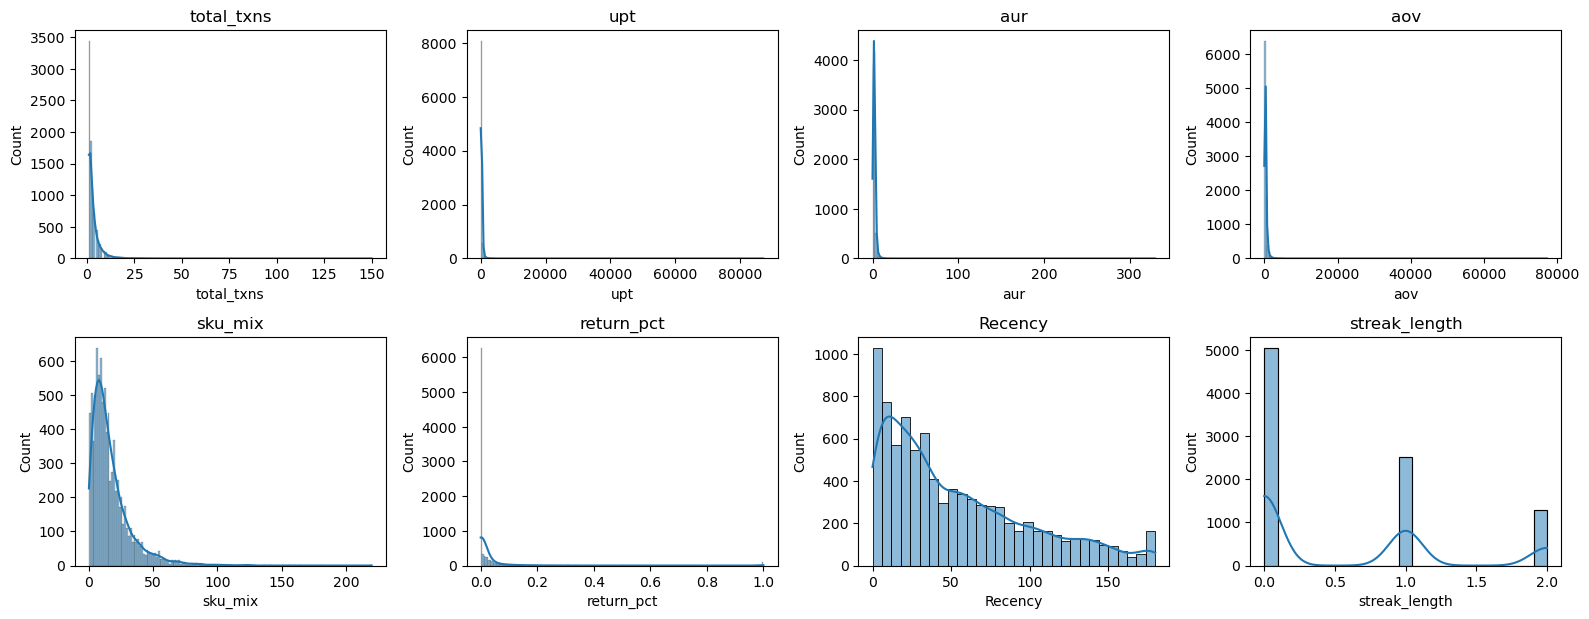

In [11]:
### Distribution of key variable
cont_regressors = ['total_txns', 'upt', 'aur', 'aov', 'sku_mix', 'return_pct', 'Recency', 'streak_length']

plt.figure(figsize=(16, 12))
for i, col in enumerate(cont_regressors, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_180[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

Take the natural log of input factors to:  
- Compresses extreme values  
- Reduces skew
- Spreads dense peaks  

Improving the performance of the logistic regression model.
- Note: a 1% increase in x changes log odds by approximately β%
- Note: using a signed log transformation due to zero/negative values, achiving the same tranformation effects but coefficients cannot be interpretted the same way.

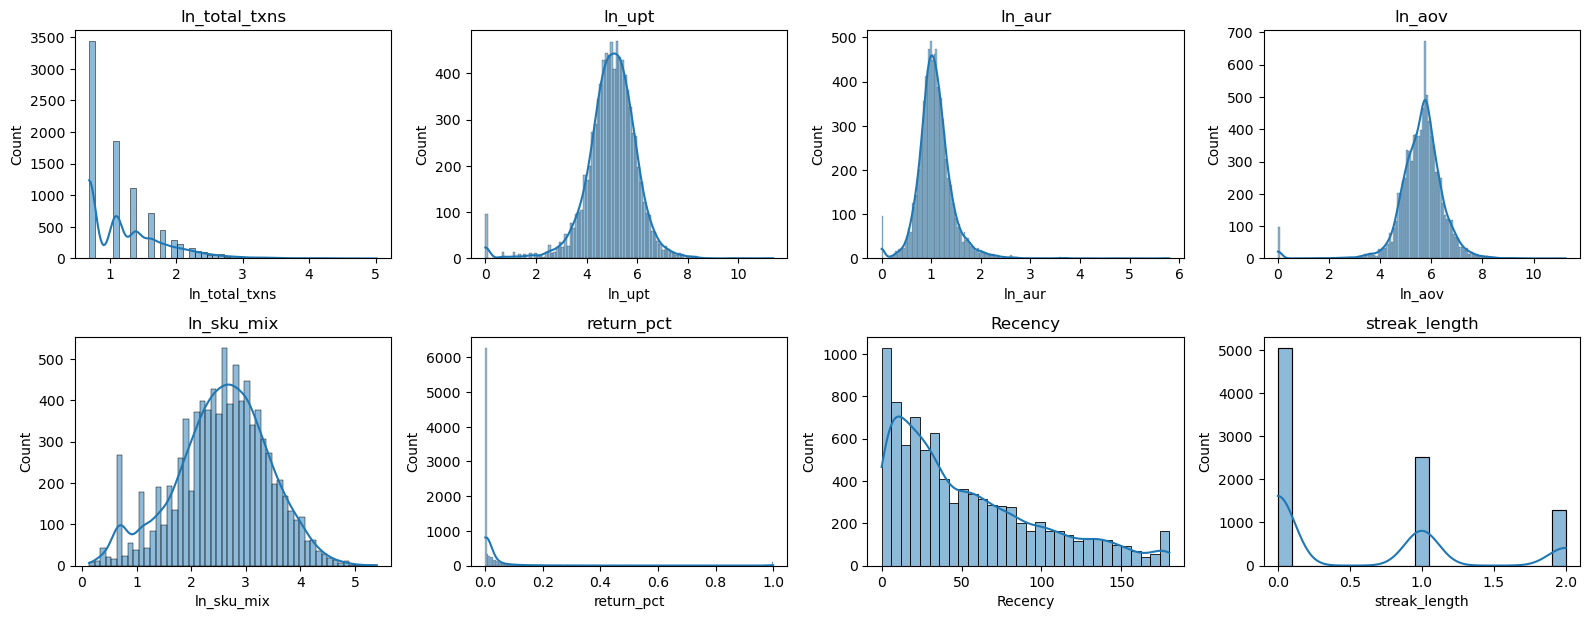

In [12]:
### Take natural log of continuous, skewed columns
cols = ['total_txns', 'upt', 'aur', 'aov', 'sku_mix']
def log_cols(df, cols):
    """
    Take natural log of continuous, skewed columns.
    """
    for c in cols:
        #df.loc[:, f"ln_{c}"] = np.log(df[c])
        df.loc[:, f"ln_{c}"] = np.log(abs(df[c])+1) * np.sign(df[c])
    return df

log_cols(df_90, cols)
log_cols(df_180, cols)


### Distribution of key variable
cont_regressors = ['ln_total_txns', 'ln_upt', 'ln_aur', 'ln_aov', 'ln_sku_mix', 'return_pct', 'Recency', 'streak_length']
plt.figure(figsize=(16, 12))
for i, col in enumerate(cont_regressors, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_180[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

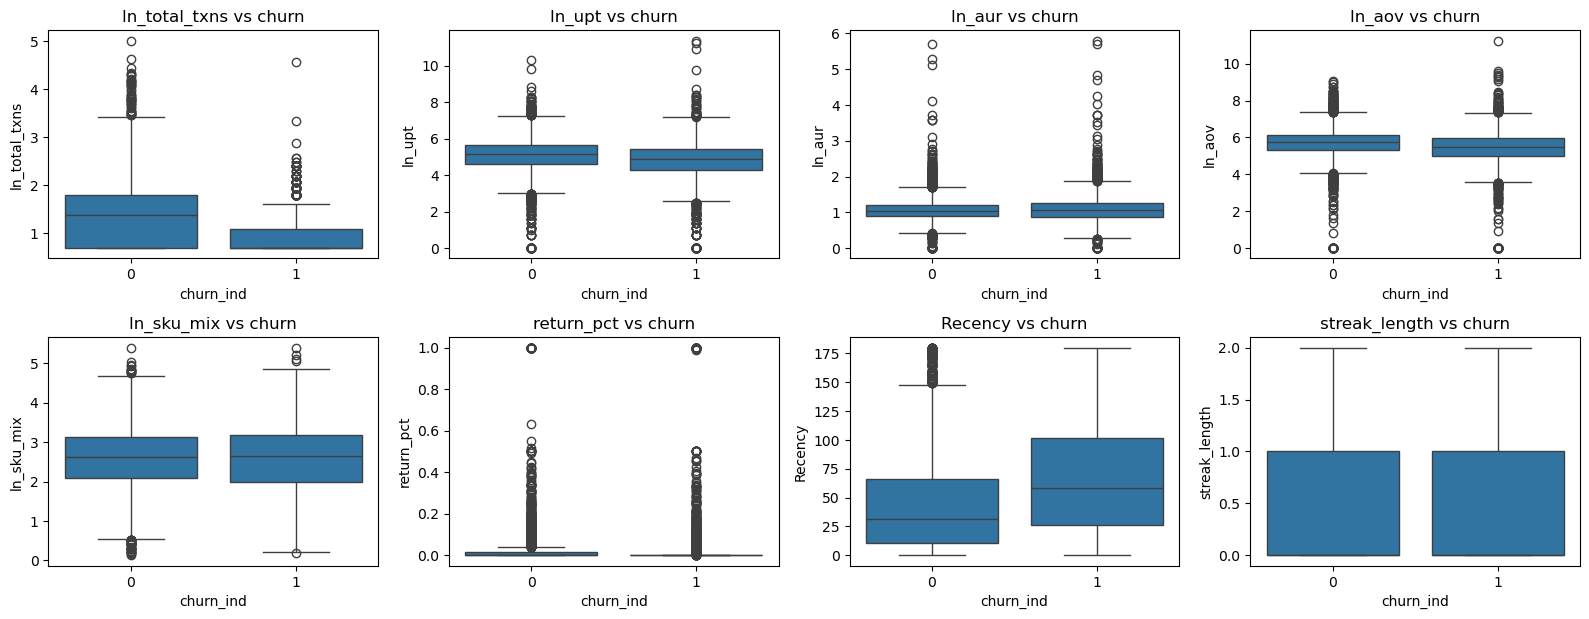

In [13]:
### Compare input factor distributions for churned vs non-chruned customers.
plt.figure(figsize=(16, 12))
for i, col in enumerate(cont_regressors, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x="churn_ind", y=col, data=df_180)
    plt.title(f"{col} vs churn")
plt.tight_layout()
plt.show()

### Plot input factors against chrun

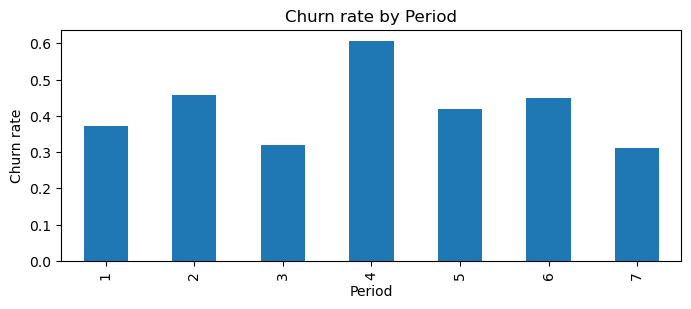

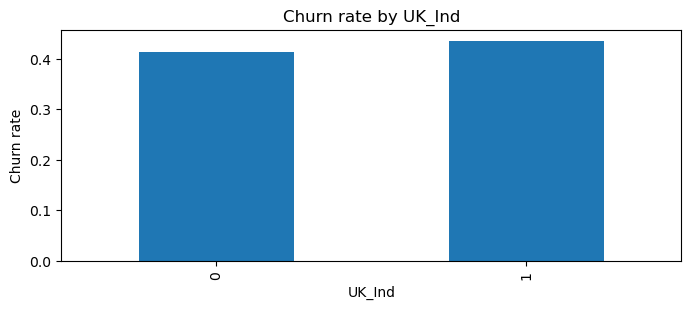

In [14]:
### Plot churn rates across time  geography for trends in seasonality, persistent change in churn accross time or geographical bias.
cat_vars = ["Period", "UK_Ind"]

for col in cat_vars:
    churn_rate = df_90.groupby(col)["churn_ind"].mean()
    churn_rate.plot(kind='bar', figsize=(8,3), title=f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.show()

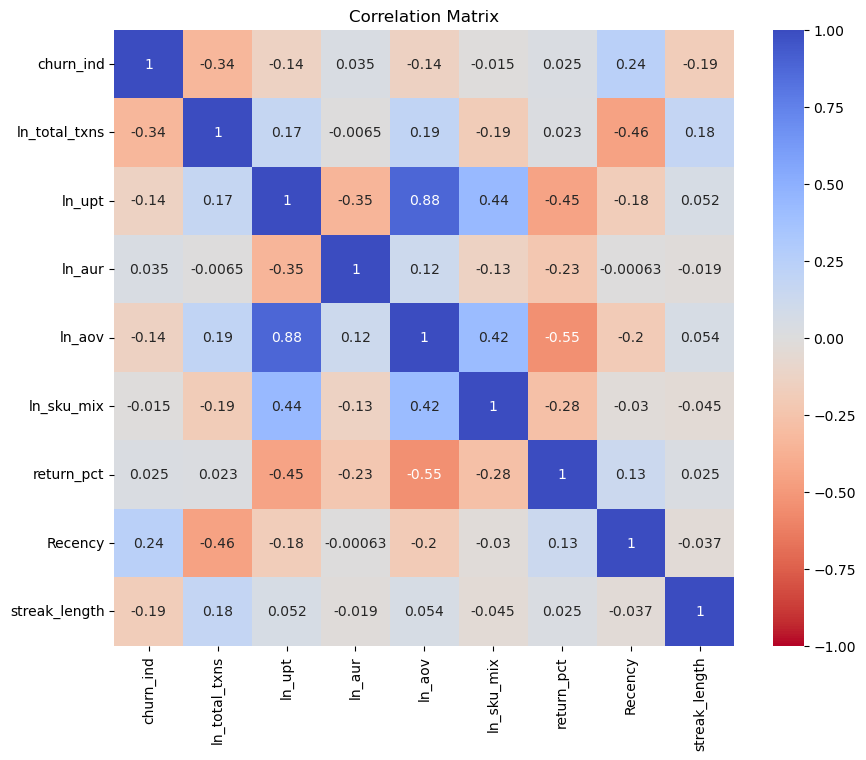

In [15]:
### Multicolinearity

# Create a mask for the upper triangle
#mask = np.triu(np.ones_like(df_180[['churn_ind']+ cont_regressors].corr(), dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_180[['churn_ind']+ cont_regressors].corr(),
    #mask=mask,
    annot=True,
    cmap="coolwarm_r",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix")
plt.show()

In [16]:
### A correlation matrix was used to assess multicollinearity among predictors.
# Unites per Transaction (UPT) is highly correlated with Avg Order Value (AOV) & Avg Unit Retail (AUR)
cont_regressors.remove('ln_upt')

In [17]:
df_180[['churn_ind']+ cont_regressors]

,churn_ind,ln_total_txns,ln_aur,ln_aov,ln_sku_mix,return_pct,Recency,streak_length
0,0,0.69,1.86,3.33,1.79,-0.00,104,0
1,0,0.69,2.14,4.97,3.00,-0.00,167,1
2,1,1.10,0.71,11.25,0.41,0.50,144,2
3,0,1.10,0.95,6.50,3.58,-0.00,5,0
4,0,1.39,0.92,6.21,3.01,-0.00,2,1
...,...,...,...,...,...,...,...,...
12346,0,0.69,1.54,6.03,2.83,-0.00,180,0
12347,1,1.10,0.99,6.73,3.31,0.11,114,1
12348,0,0.69,0.90,6.98,4.01,-0.00,28,0
12349,0,1.39,1.02,6.01,2.34,-0.00,20,1


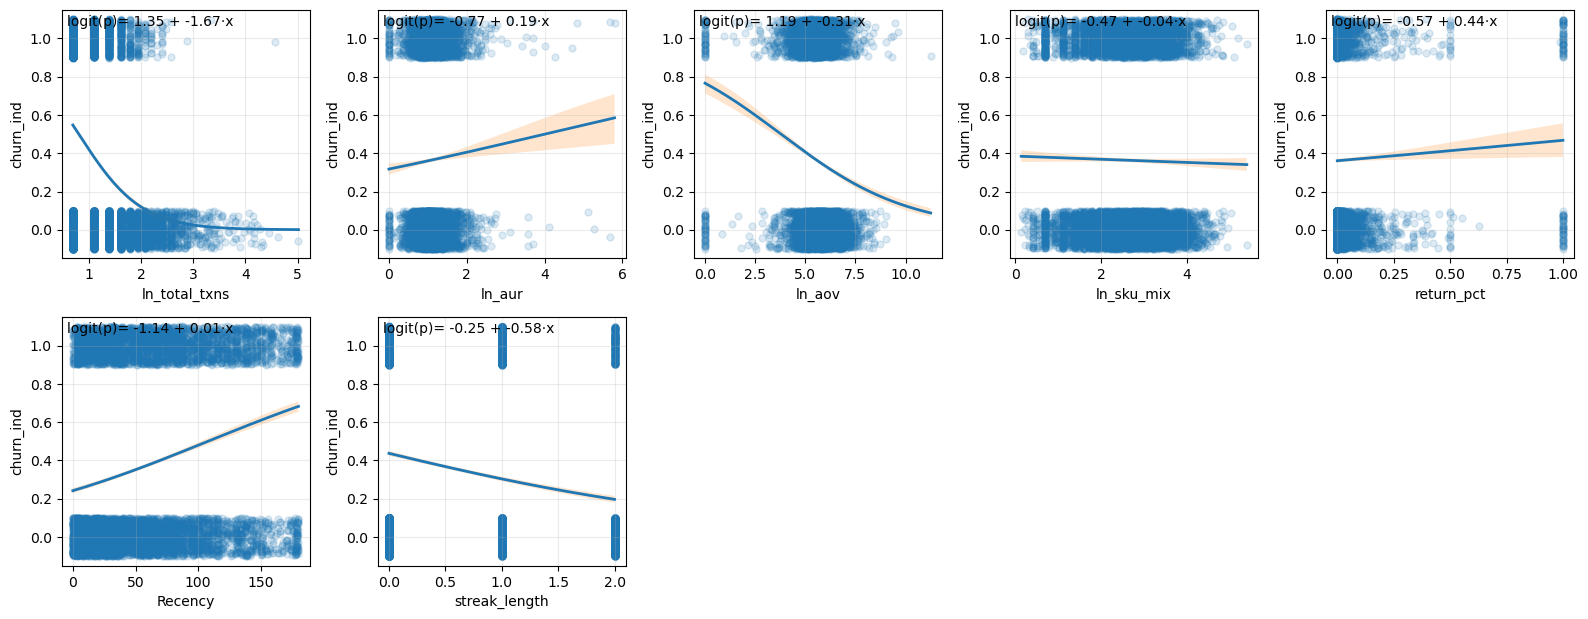

In [18]:

def plot_binary_logistic(df, x_col, y_col, ax=None, n_grid=300, jitter=0.1, alpha=0.05):
    # Use provided axes (subplot) or current axes
    if ax is None:
        ax = plt.gca()

    x = df[x_col].astype(float)
    y = df[y_col]

    # Fit logistic regression
    X = sm.add_constant(x)
    model = sm.Logit(y, X).fit(disp=False)

    # Grid for smooth curve
    xg = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)
    Xg = sm.add_constant(xg)

    # Predicted probabilities
    eta = Xg @ model.params
    p = 1 / (1 + np.exp(-eta))

    # 95% CI (Wald) for mean curve
    cov = model.cov_params()
    se_eta = np.sqrt(np.sum((Xg @ cov) * Xg, axis=1))
    z = 1.959963984540054  # ~ norm.ppf(1 - alpha/2)

    lo = 1 / (1 + np.exp(-(eta - z * se_eta)))
    hi = 1 / (1 + np.exp(-(eta + z * se_eta)))

    # Jittered scatter
    rng = np.random.default_rng(0)
    yj = y + rng.uniform(-jitter, jitter, size=len(y))

    # Plot into *this* ax
    ax.scatter(x, yj, alpha=0.15, s=25)
    ax.plot(xg, p, linewidth=2, label="Logistic fit")
    ax.fill_between(xg, lo, hi, alpha=0.2, label="95% CI")

    ax.set_ylim(-0.15, 1.15)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    #ax.set_title(f"{y_col} vs {x_col}")
    ax.grid(True, alpha=0.25)

    b0, b1 = model.params
    ax.text(0.02, 0.98, f"logit(p)= {b0:.2f} + {b1:.2f}·x",
            transform=ax.transAxes, va="top")

    return model


#####################


fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(cont_regressors):
    plot_binary_logistic(df_180, x_col=col, y_col="churn_ind", ax=axes[i])
    # optional: only show legend on first subplot to reduce clutter
    # if i == 0: axes[i].legend(frameon=False)
    # else: axes[i].legend_.remove()

# Hide any unused axes if cont_regressors < 20
for j in range(len(cont_regressors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




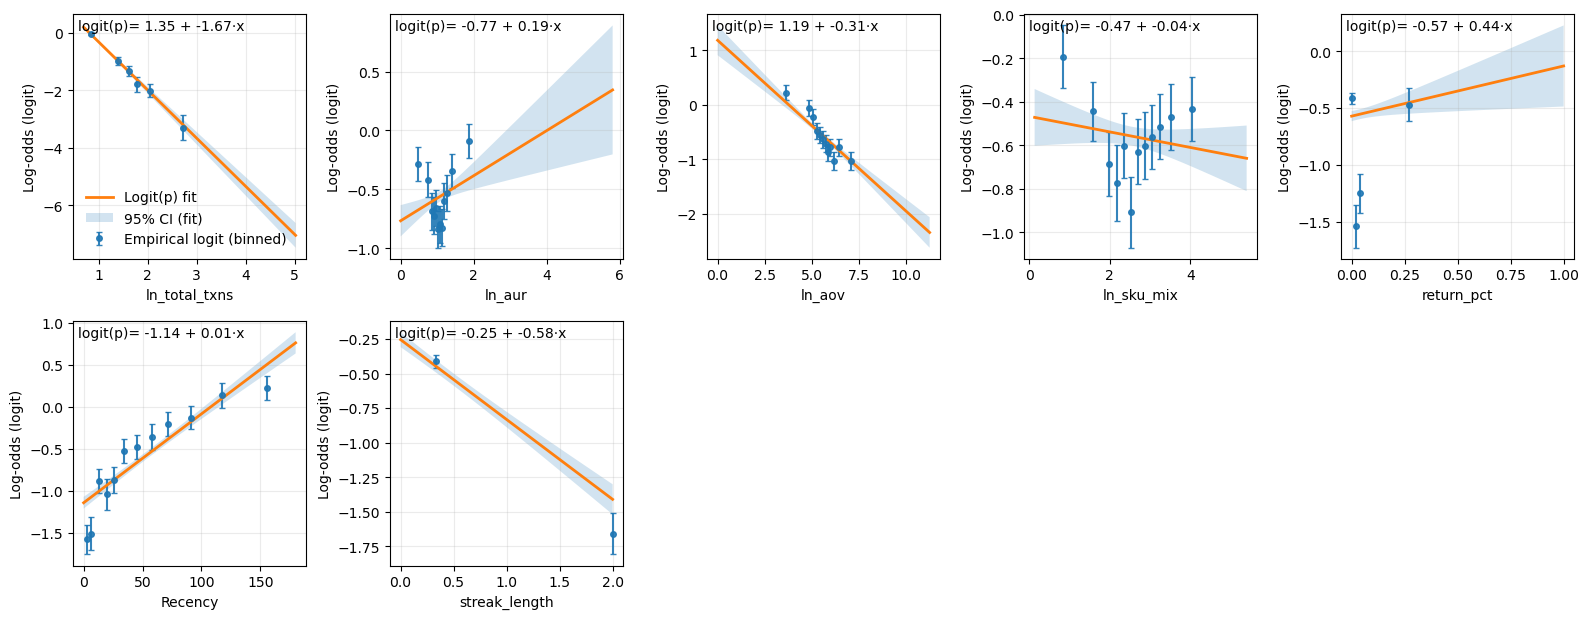

In [19]:
### probably cut this but interesting to see the linearity. also the labels are super bad ###

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def plot_logit_linearity(
    df, x_col, y_col, ax=None,
    bins=12, n_grid=300, alpha=0.05,
    min_bin_n=10, eps=1e-4
):
    """
    Linearity-in-the-logit diagnostic:
      - Empirical logit by bins (points)
      - Logistic regression linear predictor (line) + Wald CI (band)
    """
    if ax is None:
        ax = plt.gca()

    d = df[[x_col, y_col]].dropna().copy()
    x = d[x_col].astype(float).to_numpy()
    y = d[y_col].astype(int).to_numpy()

    # --- Fit logistic regression: logit(p) = b0 + b1*x ---
    X = sm.add_constant(x)
    model = sm.Logit(y, X).fit(disp=False)

    # --- Bin x and compute empirical logit ---
    # Use quantile bins so each bin has similar counts
    d["x"] = x
    d["y"] = y
    d["bin"] = pd.qcut(d["x"], q=bins, duplicates="drop")

    g = d.groupby("bin", observed=True)
    bin_n = g.size()
    x_bin = g["x"].mean()
    p_bin = g["y"].mean()

    # filter tiny bins if needed
    keep = bin_n >= min_bin_n
    x_bin = x_bin[keep]
    p_bin = p_bin[keep]
    bin_n = bin_n[keep]

    # empirical logit with clipping to avoid inf at p=0 or 1
    p_clip = np.clip(p_bin.to_numpy(), eps, 1 - eps)
    logit_emp = np.log(p_clip / (1 - p_clip))

    # Approx SE for empirical logit (delta method)
    # var(logit(p)) ≈ 1/(n*p*(1-p))
    se_emp = np.sqrt(1.0 / (bin_n.to_numpy() * p_clip * (1 - p_clip)))

    z = 1.959963984540054  # ~norm.ppf(1 - alpha/2)
    lo_emp = logit_emp - z * se_emp
    hi_emp = logit_emp + z * se_emp

    # --- Smooth model line + CI on log-odds scale ---
    xg = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)
    Xg = sm.add_constant(xg)
    eta_g = Xg @ model.params

    cov = model.cov_params()
    se_eta_g = np.sqrt(np.sum((Xg @ cov) * Xg, axis=1))
    lo_g = eta_g - z * se_eta_g
    hi_g = eta_g + z * se_eta_g

    # --- Plot ---
    ax.errorbar(
        x_bin.to_numpy(), logit_emp,
        yerr=[logit_emp - lo_emp, hi_emp - logit_emp],
        fmt="o", ms=4, capsize=2, alpha=0.9,
        label="Empirical logit (binned)"
    )
    ax.plot(xg, eta_g, linewidth=2, label="Logit(p) fit")
    ax.fill_between(xg, lo_g, hi_g, alpha=0.2, label="95% CI (fit)")

    ax.set_xlabel(x_col)
    ax.set_ylabel("Log-odds (logit)")
    ax.grid(True, alpha=0.25)

    b0, b1 = model.params
    ax.text(
        0.02, 0.98, f"logit(p)= {b0:.2f} + {b1:.2f}·x",
        transform=ax.transAxes, va="top"
    )

    return model


# ---- Grid of plots ----
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(cont_regressors):
    plot_logit_linearity(df_180, x_col=col, y_col="churn_ind", ax=axes[i], bins=12)
    # Optional: only show legend on first plot
    if i == 0:
        axes[i].legend(frameon=False)
    else:
        leg = axes[i].get_legend()
        if leg is not None:
            leg.remove()

for j in range(len(cont_regressors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

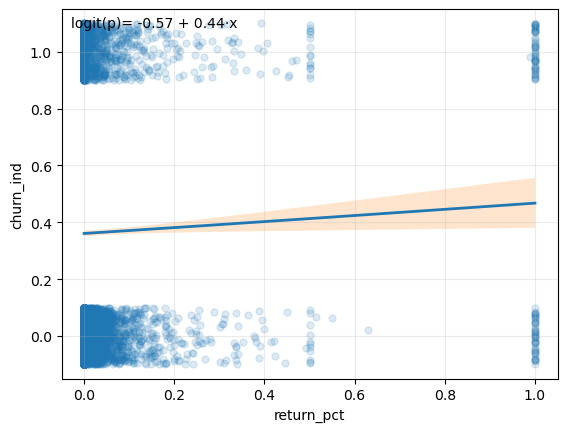

In [20]:
### delete !?!?!?!?! ###


def plot_binary_logistic____________________________________________________________________(df, x_col, y_col, n_grid=300, jitter=0.1, alpha=0.05):
     # Drop missing
    #d = df[[x_col, y_col]].dropna().copy()
    #x = d[x_col].astype(float).to_numpy()
    y = df[y_col].astype(int).to_numpy()
    
    # Fit logistic regression
    X = sm.add_constant(df[x_col])
    model = sm.Logit(df[y_col], X).fit(disp=False)

    # Grid for smooth curve
    xg = np.linspace(df[x_col].min(), df[x_col].max(), n_grid)
    Xg = sm.add_constant(xg)

    # Predicted probabilities (mean curve)
    eta = Xg @ model.params
    p = 1 / (1 + np.exp(-eta))

    # 95% CI for mean curve using parameter covariance (Wald)
    cov = model.cov_params()                # 2x2 for [const, x]
    se_eta = np.sqrt(np.sum((Xg @ cov) * Xg, axis=1))  # diag(Xg*cov*Xg')
    z = 1.959963984540054                   # ~ norm.ppf(1 - alpha/2)

    lo = 1 / (1 + np.exp(-(eta - z * se_eta)))
    hi = 1 / (1 + np.exp(-(eta + z * se_eta)))

    # Jittered scatter for binary y
    rng = np.random.default_rng(0)
    yj = df[y_col] + rng.uniform(-jitter, jitter, size=len(df[y_col]))

    # Plot
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.scatter(df[x_col], yj, alpha=0.15, s=25)
    ax.plot(xg, p, linewidth=3, label="Logistic fit")
    ax.fill_between(xg, lo, hi, alpha=0.2, label="95% CI (Wald)")

    ax.set_ylim(-0.15, 1.15)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col} vs {x_col} with logistic fit")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

    b0, b1 = model.params
    ax.text(0.02, 0.98, f"logit(p)= {b0:.2f} + {b1:.2f}·x",
            transform=ax.transAxes, va="top")

    plt.tight_layout()
    plt.show()

    return model

# usage:
plot_binary_logistic(df_180, x_col="return_pct", y_col="churn_ind")

### Comparative calculated measures across segments

## Model Results

In [21]:
## Define function for evaluating model results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(df, y_true, y_pred, y_prob, model_name):
    period_length = (df[df['Period'] == df['Period'].min()]['Observation End'][0] - df[df['Period'] == df['Period'].min()]['Observation Start'][0]).days
    print(f"\n=== {model_name} : {period_length} days ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.3f}")


#35% churn 180 days
#42% churn 90 days
dft = df_180.copy()

# Keep only rows where churn is defined (Periods 1–3) 
dft = dft[dft['Period'] <= dft['Period'].max()]

# Train = Periods 1 and 2
train_df = dft[dft['Period'] < dft['Period'].max()].copy()

# Test = Period 3 (most recent labeled period)
test_df = dft[dft['Period'] == dft['Period'].max()].copy()


# Select imput factors for modeling
regressors = ['UK_Ind', 'sale_frequency', 'streak_length', 'Recency', 
              'cx_single_purchase', 'cx_return_only', 'return_pct', 
              'ln_total_txns', 'ln_aur', 'ln_aov', 'ln_sku_mix']

X_train = train_df[regressors]
y_train = train_df['churn_ind']

X_test = test_df[regressors]
y_test = test_df['churn_ind']

# Fill missing values
#X_train = X_train.fillna(0)
#X_test = X_test.fillna(0)

### Logistic Regression

In [22]:
##################
# Scale for Logistic Regression
##################
binary_features = [
    col for col in X_train.columns
    if X_train[col].dropna().nunique() == 2
]

numeric_features = [
    col for col in X_train.columns
    if col not in binary_features
]


from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [23]:
df_180['churn_ind'].sum()/df_180['churn_ind'].count()

np.float64(0.3638314695583418)

In [24]:
## fit logistic regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]


## Fit gradiant boost
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=5,
    learning_rate=0.05
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]


# Results
evaluate(dft, y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate(dft, y_test, y_pred_gb, y_prob_gb, "Gradient Boosting (XGBoost)")


=== Logistic Regression : 180 days ===
Accuracy : 0.655
Precision: 0.449
Recall   : 0.718
F1 Score : 0.553
ROC-AUC  : 0.701

=== Gradient Boosting (XGBoost) : 180 days ===
Accuracy : 0.654
Precision: 0.444
Recall   : 0.652
F1 Score : 0.528
ROC-AUC  : 0.714


In [ ]:
threshold = 0.8
mask = y_prob_gb > threshold

from sklearn.metrics import precision_score

precision_high = precision_score(y_test[mask], y_pred_gb[mask])     # precision = tp / (tp + fp)
coverage = mask.mean()

print(f"Coverage: {coverage:.2%}")
print(f"Precision: {precision_high:.3f}", "\n")

################


thresholds = np.linspace(0.5, 0.95, 10)

for t in thresholds:
    mask = y_prob_gb > t
    if mask.sum() == 0:
        continue
    
    precision = precision_score(y_test[mask], y_pred_gb[mask])
    coverage = mask.mean()
    
    print(f"Threshold={t:.2f} | Coverage={coverage:.2%} | Precision={precision:.3f}")


# model has limited ranking power. only slightly better than random for top 4% ... this is pretty bad
# ex. “Baseline churn is 30%, but targeted group is 51% → ~1.7x higher risk” 

Coverage: 1.16%
Precision: 0.516 

Threshold=0.50 | Coverage=43.58% | Precision=0.444
Threshold=0.55 | Coverage=34.73% | Precision=0.455
Threshold=0.60 | Coverage=24.87% | Precision=0.462
Threshold=0.65 | Coverage=15.50% | Precision=0.453
Threshold=0.70 | Coverage=8.59% | Precision=0.448
Threshold=0.75 | Coverage=3.73% | Precision=0.510
Threshold=0.80 | Coverage=1.16% | Precision=0.516
Threshold=0.85 | Coverage=0.22% | Precision=0.500


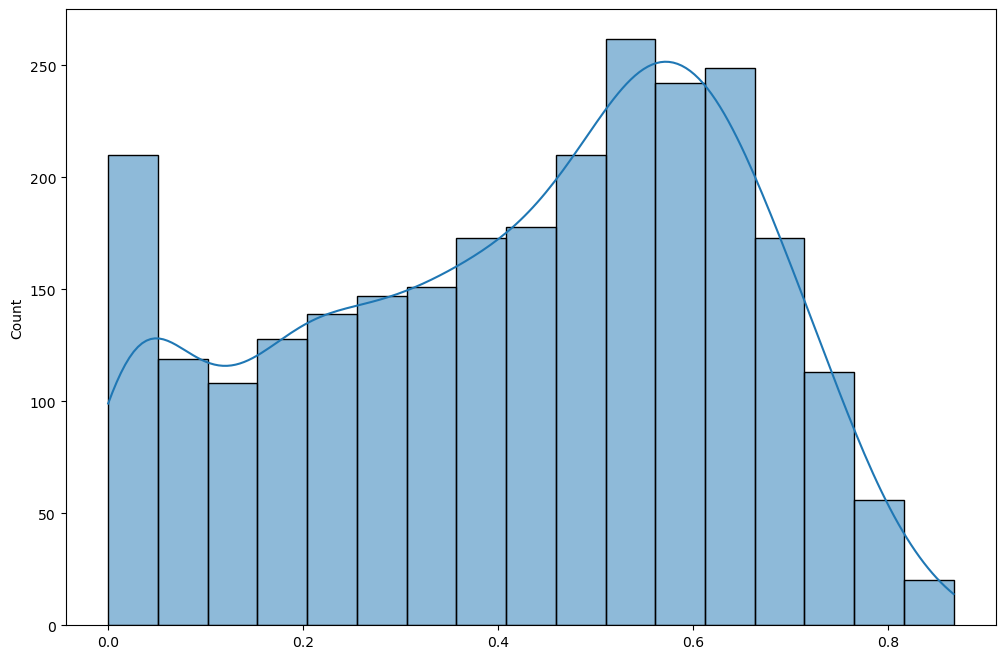

In [26]:
## Plot predicted probability

plt.figure(figsize=(12, 8))
sns.histplot(y_prob_gb, kde=True)
plt.show()

In [27]:
y_pred_gb

array([1, 0, 0, ..., 0, 0, 0], shape=(2678,))

### Gradient Boosting Model

#### Hyperparameter Tuning - Random Search

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report



param_distributions = {
    ### Function Shape
    "learning_rate": loguniform(0.01, 0.2),                     # Contribution of each tree
    "n_estimators": randint(50, 800),                           # Number of boosting stages/trees
    ### Tree shapes
    "max_depth": randint(3, 9),                                  # Deeper trees capture more interactions (but overfit quickly)
    "min_samples_split": loguniform(0.001, 0.1),                # Should depend on dataset size (min split log spacespace from 0.1% to 10% of samples)
    "min_samples_leaf": loguniform(0.001, 0.05),                # Minimum samples in each each leaf
    ### 
    "subsample": uniform(0.5, 1-0.5),                               # Fraction of rows to use for each tree
    #"max_features": ["sqrt", "log2", None],                    # Use only a subset of features for each tree (avoids single factor dominating each tree)
    "max_features": [None]                                      # Use none if feature set is small (<20)
}


search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1,
                                        n_iter_no_change=15,
                                        validation_fraction=0.1,
                                        tol=1e-4),
    param_distributions=param_distributions,
    n_iter=60,
    scoring="average_precision",                    # Area under Precision-Recall curve
            #"recall"                               # To catch them all - use if missing a churn cost much higher than false positive
            #"f1"                                   # Balance between Precision and Recall
            #"roc_auc"                              # Standard - Ability to distinguish classes but can be misleadingly high if data is imbalanced
    # Cross validation splits your data into n chunks. It trains on n-1 and tests on 1
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=1), 
    random_state=1,
    n_jobs=-1,
    verbose=1,                          # Show progress bar to see how many fits are left
    refit=True,                         # After the search finds the best parameters, take those settings & retrains model on entire dataset
)

search.fit(X_train, y_train)

print("Best CV Precision:", search.best_score_)
print("Best params:", search.best_params_)

best_model = search.best_estimator_
proba_test = best_model.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, proba_test))
print(classification_report(y_test, (proba_test >= 0.5).astype(int)))


Fitting 5 folds for each of 60 candidates, totalling 300 fits


/opt/miniconda3/envs/churn_prediction/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/churn_prediction/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/churn_prediction/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

Best CV ROC-AUC: 0.5946309696389308
Best params: {'learning_rate': np.float64(0.03487852712623489), 'max_depth': 7, 'max_features': None, 'min_samples_leaf': np.float64(0.038404930262862944), 'min_samples_split': np.float64(0.0018040513535031988), 'n_estimators': 695, 'subsample': np.float64(0.5733779454085566)}
Test ROC-AUC: 0.7291636188739367
              precision    recall  f1-score   support

           0       0.82      0.68      0.74      1883
           1       0.46      0.65      0.54       795

    accuracy                           0.67      2678
   macro avg       0.64      0.66      0.64      2678
weighted avg       0.71      0.67      0.68      2678



Interpretation
- Precision (0.46): When the model flags a customer as a churner, it is only right 46% of the time --> (many false positives).
- Recall (0.65): Out of all actually churnedrs, model caught 65% of them. Missing ~35% (False Negatives).
- F1-Score (0.54): Harmonic mean of the two scores

- Accuracy (0.67): To be ignored. If just guessed "zero churners," we'd get ~70% accuracy. Model is currently at 67%, meaning it’s actually working harder to find the churners at the cost of overall accuracy.

In [44]:
n

6175

In [ ]:
# Just a faster verison of the same thing with HistGradientBoostingClassifier
n = X_train.shape[0]
# Calculate absolute row counts for your bounds
# Ensure the min is at least 1 and the max is at least min + 1
min_leaf_lower = max(1, int(n * 0.001)) 
min_leaf_upper = max(min_leaf_lower + 1, int(n * 0.05))

# HGBC grows trees leaf-wise (best-first), whereas GBC typically grows them level-wise. 
# Leaf-wise growth is more flexible and efficient for large datasets but requires max_leaf_nodes to be carefully tuned to prevent deep, overfit branches.
hist_param_distributions = {
    ### Function Shape
    "learning_rate": loguniform(0.01, 0.3),                         # Contribution of each tree (use wider range for HGBC)
    "max_iter": randint(100, 1000),                                 # Number of boosting stages/trees (Note: max_iter == n_estimators) set high due to early_stopping=True.
    
    ### Tree shapes
    # Don't let trees have more leaves than 1/100th of your data, maxed at 255
    "max_leaf_nodes": randint(15, min(255, n // 100)),              # HGBC prioritize max_leaf_nodes over max_depth
    "min_samples_leaf": randint(min_leaf_lower, min_leaf_upper),    # Minimum samples in each each leaf

    # HGBC uses its internal histogram logic and early stopping to manage variance instead of row-based subsampling.
    # max_bins defaults to 255 - Test if "coarser" features help generalization
    "max_bins": randint(32, 255),                                   # Binning granularity

    # Prevent overfitting by penalizing large weights - adds penalty proportional to the square of the magnitude of the model's coefficients to the loss function
    "l2_regularization": loguniform(1e-6, 10.0)  
}


hist_search = RandomizedSearchCV(
                estimator=HistGradientBoostingClassifier(
                random_state=1,
                early_stopping=True,
                validation_fraction=0.1,            # For early stop, model needs to test itself on data it hasn't seen. It trains on 90%, then checks its score on this 10%
                n_iter_no_change=15,                # How many trees the model is willing to build without seeing an improvement before it gives up
                tol=1e-4                            # "Tolerance" // what counts as a "real" improvement
                    # Note: If learning_rate is extremely small (~0.001), model might improve so slowly that it triggers tol and stops too early. 
                    # If using tiny learning rate, one should also make tol smaller or n_iter_no_change larger. 
                ),
    param_distributions=hist_param_distributions,
    n_iter=60,
    scoring="average_precision",                    # Area under Precision-Recall curve
            #"recall"                               # To catch them all - use if missing a churn cost much higher than false positive
            #"f1"                                   # Balance between Precision and Recall
            #"roc_auc"                              # Standard - Ability to distinguish classes but can be misleadingly high if data is imbalanced
    # Cross validation splits your data into n chunks. It trains on n-1 and tests on 1
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=1), 
    random_state=1,
    n_jobs=-1,
    verbose=1,                          # Show progress bar to see how many fits are left
    refit=True,                         # After the search finds the best parameters, take those settings & retrains model on entire dataset
)

hist_search.fit(X_train, y_train)

print("Best CV Precision:", hist_search.best_score_)
print("Best params:", hist_search.best_params_)

best_model = hist_search.best_estimator_
proba_test = best_model.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, proba_test))
print(classification_report(y_test, (proba_test >= 0.5).astype(int)))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV ROC-AUC: 0.5932763361797716
Best params: {'l2_regularization': np.float64(0.023345861532847307), 'learning_rate': np.float64(0.09458866124759048), 'max_bins': 57, 'max_iter': 467, 'max_leaf_nodes': 49, 'min_samples_leaf': 288}
Test ROC-AUC: 0.721827540022111
              precision    recall  f1-score   support

           0       0.82      0.67      0.74      1883
           1       0.45      0.65      0.54       795

    accuracy                           0.66      2678
   macro avg       0.64      0.66      0.64      2678
weighted avg       0.71      0.66      0.68      2678



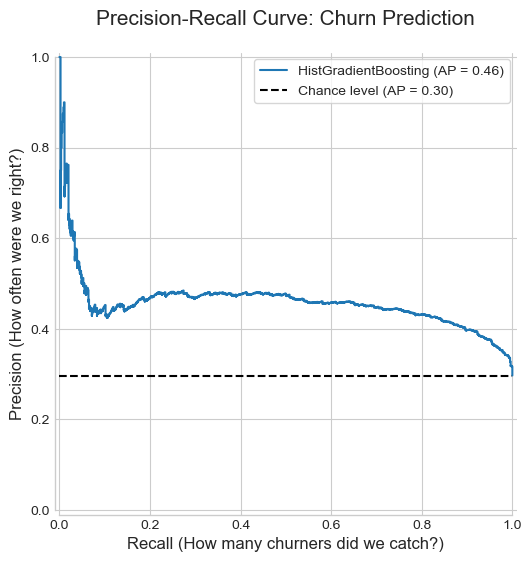

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Set a nice style (optional)
plt.style.use('seaborn-v0_8-whitegrid') 

# 1. Create the plot using the best model from your search
# This automatically handles probability calculation and threshold sweeping
fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_estimator(
    hist_search.best_estimator_, 
    X_test, 
    y_test, 
    name="HistGradientBoosting",
    plot_chance_level=True,  # Shows the baseline for imbalanced data
    despine=True,            # Removes top/right borders for a cleaner look
    ax=ax
)

# 2. Add custom styling to make it "pretty"
ax.set_title("Precision-Recall Curve: Churn Prediction", fontsize=15, pad=20)
ax.set_xlabel("Recall (How many churners did we catch?)", fontsize=12)
ax.set_ylabel("Precision (How often were we right?)", fontsize=12)
ax.legend(loc="upper right", frameon=True)

plt.show()

A steep drop-off at the beginning suggests the model is struggling even with its most "certain" predictions.

#### random search v2 ?


In [ ]:
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score
)

from xgboost import XGBClassifier

# Optional: for Bayesian optimization
import optuna

# ---------------------------
# 1) Minimal preprocessing + model
# ---------------------------
def build_pipeline(random_state=1):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",     # good for churn imbalance
        tree_method="hist",
        n_estimators=5000,       # large, rely on early stopping
        random_state=random_state,
        n_jobs=-1
    )
    return model


def evaluate(pipe, X, y, label=""):
    proba = pipe.predict_proba(X)[:, 1]
    roc = roc_auc_score(y, proba)
    pr = average_precision_score(y, proba)
    print(f"{label} ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")
    return roc, pr


# ---------------------------
# 2) Random Search (broad)
# ---------------------------
def random_search_xgb(X_train, y_train, X_test, y_test, random_state=42):
    model = build_pipeline(random_state=random_state)

    # Optional but recommended for churn imbalance:
    # Set scale_pos_weight around neg/pos ratio as a starting point.
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    base_spw = (neg / max(pos, 1))

    param_distributions = {
        "learning_rate": np.logspace(-2.5, -0.7, 30),  # ~0.003 to ~0.2
        "max_depth": [2, 3, 4, 5, 6, 8],
        "min_child_weight": np.logspace(-1, 1.2, 20),  # ~0.1 to ~16
        "subsample": np.linspace(0.5, 1.0, 11),
        "colsample_bytree": np.linspace(0.5, 1.0, 11),
        "gamma": np.linspace(0.0, 5.0, 21),
        "reg_alpha": np.logspace(-6, 0, 25),
        "reg_lambda": np.logspace(-2, 2, 25),
        # optional: tune around imbalance ratio
        "scale_pos_weight": [base_spw * f for f in [0.5, 0.75, 1.0, 1.25, 1.5]],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=40,
        scoring="average_precision",   # optimize PR-AUC
        cv=cv,
        verbose=1,
        n_jobs=-1,
        refit=True,
        random_state=random_state
    )

    # Early stopping uses your test period as a validation set during search fits.
    # IMPORTANT: If you want *pure* test, create a small validation split from train_df instead.
    fit_params = {
        "model__eval_set": [(X_test, y_test)],
        "model__verbose": False
    }

    search.fit(X_train, y_train, **fit_params)

    best_pipe = search.best_estimator_
    best_params = search.best_params_
    best_score = search.best_score_

    print("\nBest Random Search PR-AUC (CV):", best_score)
    print("Best Params:", best_params)

    return best_pipe, best_params, best_score

#### Hyperparameter Tuning - Bayesian Optimization

In [ ]:
# ---------------------------
# 3) Bayesian Optimization (Optuna)
# ---------------------------
def bayes_opt_xgb(best_params_from_random, X_train, y_train, X_es, y_es,
                 n_trials=60, random_state=42):
    """
    Bayesian optimization on train with CV scoring.
    Uses X_es/y_es only for early stopping inside each CV fold's fit call.
    """

    # Convert best params to model params (strip pipeline prefix)
    bp = {k.replace("model__", ""): v for k, v in best_params_from_random.items()}

    # Recompute imbalance baseline for this training set
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    base_spw = (neg / max(pos, 1))

    def objective(trial):
        params = {
            "learning_rate": trial.suggest_float(
                "learning_rate",
                max(0.005, bp.get("learning_rate", 0.05) / 3),
                min(0.3,  bp.get("learning_rate", 0.05) * 3),
                log=True
            ),
            "max_depth": trial.suggest_int(
                "max_depth",
                max(2, bp.get("max_depth", 4) - 2),
                min(10, bp.get("max_depth", 4) + 2)
            ),
            "min_child_weight": trial.suggest_float(
                "min_child_weight",
                max(0.1, bp.get("min_child_weight", 1.0) / 3),
                min(50.0, bp.get("min_child_weight", 1.0) * 3),
                log=True
            ),
            "subsample": trial.suggest_float(
                "subsample",
                max(0.4, float(bp.get("subsample", 0.8)) - 0.2),
                min(1.0, float(bp.get("subsample", 0.8)) + 0.2)
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                max(0.4, float(bp.get("colsample_bytree", 0.8)) - 0.2),
                min(1.0, float(bp.get("colsample_bytree", 0.8)) + 0.2)
            ),
            "gamma": trial.suggest_float(
                "gamma",
                max(0.0, float(bp.get("gamma", 0.0)) - 1.0),
                float(bp.get("gamma", 0.0)) + 3.0
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                max(1e-8, float(bp.get("reg_alpha", 1e-5)) / 10),
                max(1e-7, float(bp.get("reg_alpha", 1e-5)) * 10),
                log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                max(1e-4, float(bp.get("reg_lambda", 1.0)) / 10),
                float(bp.get("reg_lambda", 1.0)) * 10,
                log=True
            ),
            "scale_pos_weight": trial.suggest_float(
                "scale_pos_weight",
                max(0.1, base_spw * 0.5),
                base_spw * 1.5
            )
        }

        # Pipeline each trial (imputer + model)
        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                n_estimators=5000,
                random_state=random_state,
                model__early_stopping_rounds= 50,
                n_jobs=-1,
                **params
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        pr_aucs = []

        for tr_idx, va_idx in cv.split(X_train, y_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

            # Early stop on X_va (best practice) rather than X_es:
            pipe.fit(
                X_tr, y_tr,
                model__eval_set=[(X_va, y_va)],
                model__early_stopping_rounds=50,
                model__verbose=False
            )

            proba = pipe.predict_proba(X_va)[:, 1]
            pr_aucs.append(average_precision_score(y_va, proba))

        return float(np.mean(pr_aucs))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    print("\nBest Bayes PR-AUC:", study.best_value)
    print("Best Bayes Params:", study.best_params)
    return study

### Comparing model results

In [ ]:
# ---------------------------
# 4) Run both stages + final fit
# ---------------------------
best_pipe_rs, best_params_rs, best_score_rs = random_search_xgb(
    X_train, y_train, X_test, y_test
)

print("\nAfter Random Search (fit includes early stopping on test period):")
evaluate(best_pipe_rs, X_train, y_train, label="TRAIN")
evaluate(best_pipe_rs, X_test, y_test, label="TEST (Period max)")

# Bayes optimization (CV-based). We DO NOT use X_test inside the CV scoring;
# early stopping uses fold validation sets.
study = bayes_opt_xgb(best_params_rs, X_train, y_train, X_test, y_test, n_trials=60)

# Fit final model on all training periods with best bayes params,
# early stop on test period (still okay if you're using test as a "final labeled period" not a pure holdout).
final_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_estimators=5000,
        random_state=42,
        n_jobs=-1,
        **study.best_params
    ))
])

final_pipe.fit(
    X_train, y_train,
    model__eval_set=[(X_test, y_test)],
    model__early_stopping_rounds=50,
    model__verbose=False
)

print("\nFinal model performance:")
evaluate(final_pipe, X_test, y_test, label="TEST (Period max)")

In [ ]:
#### Not total sure about this code chunk / what its for ####
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier

# --- impute once (numeric/binary only) ---
imp = SimpleImputer(strategy="median")
X_train_imp = imp.fit_transform(X_train)
X_test_imp  = imp.transform(X_test)


# --- model with early stopping in constructor ---
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_estimators=5000,
    early_stopping_rounds=50,   # ✅ here
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "learning_rate": np.logspace(-2.5, -0.7, 30),
    "max_depth": [2, 3, 4, 5, 6, 8],
    "min_child_weight": np.logspace(-1, 1.2, 20),
    "subsample": np.linspace(0.5, 1.0, 11),
    "colsample_bytree": np.linspace(0.5, 1.0, 11),
    "gamma": np.linspace(0.0, 5.0, 21),
    "reg_alpha": np.logspace(-6, 0, 25),
    "reg_lambda": np.logspace(-2, 2, 25),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    refit=True,
    random_state=1
)

# ✅ eval_set is now consistent with training features (both imputed)
search.fit(X_train_imp, y_train, eval_set=[(X_test_imp, y_test)], verbose=False)

best_model = search.best_estimator_
print("Best PR-AUC (CV):", search.best_score_)
print("Best Params:", search.best_params_)


### ~Interpreting SHAP values

### ~Customer Segmentation

## ~Aditional Analysis: Temporal Factors